## Contents

### Part 1
Event level xG and goal modeling analysis

### Part 2
Pre match match outcome, goal prediction, Elo analysis, and simulation

All original code has been preserved. Section labels were added for readability and submission formatting.


# Part 1
## Event Level xG and Goal Modeling Analysis

## Section 1.1
### Data loading, feature setup, train test split, and multi output regression

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import GroupShuffleSplit
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Load data
df = pd.read_csv("df_all_buckets.csv")

# Features
features = [
    "final_third_entries",
    "final_third_passes",
    "final_third_carries",
    "pressures",
    "shots_against",
    "sot_against",
    "xg_for",
    "xg_against",
    "final_third_against",
    "pressure_against",
    "shot_diff",
    "sot_diff",
    "xg_diff",
    "final_third_diff",
    "pressure_diff",
    "n_carries",
    "n_dribbles",
    "n_passes",
    "n_passes_complete",
    "pass_completion_rate",
    "carries_against",
    "dribbles_against",
    "passes_against",
    "passes_complete_against",
    "carry_diff",
    "dribble_diff",
    "pass_diff",
    "pass_complete_diff"
]

# Targets
targets = ["goals_scored", "goals_conceded"]

# Required columns
required_cols = features + targets + ["match_id"]

# Keep only needed rows
df = df.dropna(subset=required_cols).copy()

# Optional cleanup for impossible values
df["goals_scored"] = pd.to_numeric(df["goals_scored"], errors="coerce")
df["goals_conceded"] = pd.to_numeric(df["goals_conceded"], errors="coerce")
df = df.dropna(subset=["goals_scored", "goals_conceded"]).copy()

# Build X, y, groups
X = df[features]
y = df[targets]
groups = df["match_id"]

# Train test split grouped by match
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

test_df = df.iloc[test_idx].copy()

# Train model
model = MultiOutputRegressor(
    RandomForestRegressor(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1
    )
)

model.fit(X_train, y_train)

# Predict
pred = model.predict(X_test)

test_df["pred_goals_scored_raw"] = pred[:, 0]
test_df["pred_goals_conceded_raw"] = pred[:, 1]

# Rounded predictions for exact score and outcome checks
test_df["pred_goals_scored"] = np.clip(np.rint(test_df["pred_goals_scored_raw"]), 0, None).astype(int)
test_df["pred_goals_conceded"] = np.clip(np.rint(test_df["pred_goals_conceded_raw"]), 0, None).astype(int)

# xG only baseline
# This baseline uses only xg_for and xg_against directly as the prediction
test_df["baseline_goals_scored_raw"] = test_df["xg_for"]
test_df["baseline_goals_conceded_raw"] = test_df["xg_against"]

test_df["baseline_goals_scored"] = np.clip(np.rint(test_df["baseline_goals_scored_raw"]), 0, None).astype(int)
test_df["baseline_goals_conceded"] = np.clip(np.rint(test_df["baseline_goals_conceded_raw"]), 0, None).astype(int)

# Outcome helper
def get_outcome(scored, conceded):
    if scored > conceded:
        return "Win"
    elif scored < conceded:
        return "Loss"
    return "Draw"

# RMSE helper
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# Actual outcomes
test_df["actual_outcome"] = test_df.apply(
    lambda r: get_outcome(r["goals_scored"], r["goals_conceded"]),
    axis=1
)

# Model outcomes
test_df["pred_outcome"] = test_df.apply(
    lambda r: get_outcome(r["pred_goals_scored"], r["pred_goals_conceded"]),
    axis=1
)

# Baseline outcomes
test_df["baseline_outcome"] = test_df.apply(
    lambda r: get_outcome(r["baseline_goals_scored"], r["baseline_goals_conceded"]),
    axis=1
)

# Model metrics
model_mae_scored = mean_absolute_error(test_df["goals_scored"], test_df["pred_goals_scored_raw"])
model_mae_conceded = mean_absolute_error(test_df["goals_conceded"], test_df["pred_goals_conceded_raw"])
model_rmse_scored = rmse(test_df["goals_scored"], test_df["pred_goals_scored_raw"])
model_rmse_conceded = rmse(test_df["goals_conceded"], test_df["pred_goals_conceded_raw"])
model_total_mae = model_mae_scored + model_mae_conceded

model_exact_score_accuracy = (
    (
        (test_df["pred_goals_scored"] == test_df["goals_scored"]) &
        (test_df["pred_goals_conceded"] == test_df["goals_conceded"])
    ).mean()
)

model_outcome_accuracy = (
    (test_df["pred_outcome"] == test_df["actual_outcome"]).mean()
)

# Baseline metrics
baseline_mae_scored = mean_absolute_error(test_df["goals_scored"], test_df["baseline_goals_scored_raw"])
baseline_mae_conceded = mean_absolute_error(test_df["goals_conceded"], test_df["baseline_goals_conceded_raw"])
baseline_rmse_scored = rmse(test_df["goals_scored"], test_df["baseline_goals_scored_raw"])
baseline_rmse_conceded = rmse(test_df["goals_conceded"], test_df["baseline_goals_conceded_raw"])
baseline_total_mae = baseline_mae_scored + baseline_mae_conceded

baseline_exact_score_accuracy = (
    (
        (test_df["baseline_goals_scored"] == test_df["goals_scored"]) &
        (test_df["baseline_goals_conceded"] == test_df["goals_conceded"])
    ).mean()
)

baseline_outcome_accuracy = (
    (test_df["baseline_outcome"] == test_df["actual_outcome"]).mean()
)

# Edge checks
edge_scored_mae = model_mae_scored < baseline_mae_scored
edge_conceded_mae = model_mae_conceded < baseline_mae_conceded
edge_total_mae = model_total_mae < baseline_total_mae
edge_exact_score = model_exact_score_accuracy > baseline_exact_score_accuracy
edge_outcome = model_outcome_accuracy > baseline_outcome_accuracy

# Feature importance
importances_scored = model.estimators_[0].feature_importances_
importances_conceded = model.estimators_[1].feature_importances_
avg_importance = (importances_scored + importances_conceded) / 2

feature_importance_df = pd.DataFrame({
    "feature": features,
    "importance_avg": avg_importance,
    "importance_goals_scored": importances_scored,
    "importance_goals_conceded": importances_conceded
}).sort_values("importance_avg", ascending=False)

# Save outputs
save_cols = [
    "match_id",
    "goals_scored",
    "goals_conceded",
    "actual_outcome",
    "pred_goals_scored_raw",
    "pred_goals_conceded_raw",
    "pred_goals_scored",
    "pred_goals_conceded",
    "pred_outcome",
    "baseline_goals_scored_raw",
    "baseline_goals_conceded_raw",
    "baseline_goals_scored",
    "baseline_goals_conceded",
    "baseline_outcome"
]

for col in save_cols:
    if col not in test_df.columns:
        test_df[col] = np.nan

test_df[save_cols].to_csv("score_prediction_results.csv", index=False)
feature_importance_df.to_csv("feature_importance_score_model.csv", index=False)

# Print results
print("\nModel evaluation on held out matches\n")

print(f"Test rows: {len(test_df)}")
print(f"Unique matches in test: {test_df['match_id'].nunique()}")

print("\nYour model")
print(f"Goals scored MAE: {model_mae_scored:.4f}")
print(f"Goals conceded MAE: {model_mae_conceded:.4f}")
print(f"Goals scored RMSE: {model_rmse_scored:.4f}")
print(f"Goals conceded RMSE: {model_rmse_conceded:.4f}")
print(f"Total score MAE: {model_total_mae:.4f}")
print(f"Exact score accuracy: {model_exact_score_accuracy:.4%}")
print(f"Outcome accuracy: {model_outcome_accuracy:.4%}")

print("\nxG only baseline")
print(f"Goals scored MAE: {baseline_mae_scored:.4f}")
print(f"Goals conceded MAE: {baseline_mae_conceded:.4f}")
print(f"Goals scored RMSE: {baseline_rmse_scored:.4f}")
print(f"Goals conceded RMSE: {baseline_rmse_conceded:.4f}")
print(f"Total score MAE: {baseline_total_mae:.4f}")
print(f"Exact score accuracy: {baseline_exact_score_accuracy:.4%}")
print(f"Outcome accuracy: {baseline_outcome_accuracy:.4%}")

print("\nEdge checks")
print(f"Better than xG baseline on goals scored MAE: {edge_scored_mae}")
print(f"Better than xG baseline on goals conceded MAE: {edge_conceded_mae}")
print(f"Better than xG baseline on total score MAE: {edge_total_mae}")
print(f"Better than xG baseline on exact score accuracy: {edge_exact_score}")
print(f"Better than xG baseline on outcome accuracy: {edge_outcome}")

print("\nTop 15 features")
print(feature_importance_df.head(15).to_string(index=False))

print("\nSaved files")
print("score_prediction_results.csv")
print("feature_importance_score_model.csv")

## Section 1.2
### xG evaluation, residual analysis, calibration, and feature based error modeling

In [ ]:
import pandas as pd
import numpy as np

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupShuffleSplit

# Make sure these columns exist
required_cols = ["xg_for", "xg_against", "goals_scored", "goals_conceded", "match_id"]
missing_required = [c for c in required_cols if c not in df.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

# Copy and clean
work_df = df.copy()

for col in ["xg_for", "xg_against", "goals_scored", "goals_conceded"]:
    work_df[col] = pd.to_numeric(work_df[col], errors="coerce")

work_df = work_df.dropna(subset=required_cols).copy()

# Your feature list for explaining when xG fails
feature_cols = [
    "final_third_entries",
    "final_third_passes",
    "final_third_carries",
    "pressures",
    "shots_against",
    "sot_against",
    "xg_against",
    "final_third_against",
    "pressure_against",
    "shot_diff",
    "sot_diff",
    "xg_diff",
    "final_third_diff",
    "pressure_diff",
    "n_carries",
    "n_dribbles",
    "n_passes",
    "n_passes_complete",
    "pass_completion_rate",
    "carries_against",
    "dribbles_against",
    "passes_against",
    "passes_complete_against",
    "carry_diff",
    "dribble_diff",
    "pass_diff",
    "pass_complete_diff"
]

feature_cols = [c for c in feature_cols if c in work_df.columns]

# Create xG residuals
# Positive residual means team scored more than xG expected
# Negative residual means team scored less than xG expected
work_df["xg_residual_for"] = work_df["goals_scored"] - work_df["xg_for"]
work_df["xg_residual_against"] = work_df["goals_conceded"] - work_df["xg_against"]

# Absolute residual tells you size of miss regardless of direction
work_df["xg_abs_error_for"] = np.abs(work_df["xg_residual_for"])
work_df["xg_abs_error_against"] = np.abs(work_df["xg_residual_against"])

# Outcome labels
def get_outcome(scored, conceded):
    if scored > conceded:
        return "Win"
    elif scored < conceded:
        return "Loss"
    return "Draw"

work_df["actual_outcome"] = work_df.apply(
    lambda r: get_outcome(r["goals_scored"], r["goals_conceded"]),
    axis=1
)

# Overall xG quality checks
mae_for = mean_absolute_error(work_df["goals_scored"], work_df["xg_for"])
mae_against = mean_absolute_error(work_df["goals_conceded"], work_df["xg_against"])
rmse_for = np.sqrt(mean_squared_error(work_df["goals_scored"], work_df["xg_for"]))
rmse_against = np.sqrt(mean_squared_error(work_df["goals_conceded"], work_df["xg_against"]))
r2_for = r2_score(work_df["goals_scored"], work_df["xg_for"])
r2_against = r2_score(work_df["goals_conceded"], work_df["xg_against"])
corr_for = work_df["xg_for"].corr(work_df["goals_scored"])
corr_against = work_df["xg_against"].corr(work_df["goals_conceded"])

# Simple linear regression checks
reg_for = LinearRegression()
reg_for.fit(work_df[["xg_for"]], work_df["goals_scored"])

reg_against = LinearRegression()
reg_against.fit(work_df[["xg_against"]], work_df["goals_conceded"])

# Calibration buckets for xg_for
# This answers: when xG says about 1.5, what do teams actually score on average?
bucket_edges = [-0.001, 0.5, 1.0, 1.5, 2.0, 2.5, 10.0]
bucket_labels = ["0 to 0.5", "0.5 to 1.0", "1.0 to 1.5", "1.5 to 2.0", "2.0 to 2.5", "2.5+"]

work_df["xg_for_bucket"] = pd.cut(
    work_df["xg_for"],
    bins=bucket_edges,
    labels=bucket_labels
)

work_df["xg_against_bucket"] = pd.cut(
    work_df["xg_against"],
    bins=bucket_edges,
    labels=bucket_labels
)

calibration_for = (
    work_df.groupby("xg_for_bucket", observed=False)
    .agg(
        n=("xg_for", "size"),
        avg_xg_for=("xg_for", "mean"),
        avg_goals_scored=("goals_scored", "mean"),
        avg_residual_for=("xg_residual_for", "mean"),
        avg_abs_error_for=("xg_abs_error_for", "mean")
    )
    .reset_index()
)

calibration_against = (
    work_df.groupby("xg_against_bucket", observed=False)
    .agg(
        n=("xg_against", "size"),
        avg_xg_against=("xg_against", "mean"),
        avg_goals_conceded=("goals_conceded", "mean"),
        avg_residual_against=("xg_residual_against", "mean"),
        avg_abs_error_against=("xg_abs_error_against", "mean")
    )
    .reset_index()
)

# Residual analysis by actual outcome
residual_by_outcome = (
    work_df.groupby("actual_outcome")
    .agg(
        n=("actual_outcome", "size"),
        avg_xg_for=("xg_for", "mean"),
        avg_goals_scored=("goals_scored", "mean"),
        avg_residual_for=("xg_residual_for", "mean"),
        avg_abs_error_for=("xg_abs_error_for", "mean"),
        avg_xg_against=("xg_against", "mean"),
        avg_goals_conceded=("goals_conceded", "mean"),
        avg_residual_against=("xg_residual_against", "mean"),
        avg_abs_error_against=("xg_abs_error_against", "mean")
    )
    .reset_index()
)

# Optional home away analysis if a likely column exists
home_away_cols = [c for c in work_df.columns if c.lower() in ["home_away", "venue", "is_home", "home"]]
home_away_summary = None

if len(home_away_cols) > 0:
    ha_col = home_away_cols[0]
    home_away_summary = (
        work_df.groupby(ha_col)
        .agg(
            n=(ha_col, "size"),
            avg_xg_for=("xg_for", "mean"),
            avg_goals_scored=("goals_scored", "mean"),
            avg_residual_for=("xg_residual_for", "mean"),
            avg_abs_error_for=("xg_abs_error_for", "mean"),
            avg_xg_against=("xg_against", "mean"),
            avg_goals_conceded=("goals_conceded", "mean"),
            avg_residual_against=("xg_residual_against", "mean"),
            avg_abs_error_against=("xg_abs_error_against", "mean")
        )
        .reset_index()
    )

# Correlation of features with residuals
# This helps identify what is associated with xG under or over performance
corr_rows = []
for col in feature_cols:
    tmp = work_df[[col, "xg_residual_for", "xg_abs_error_for", "xg_residual_against", "xg_abs_error_against"]].copy()
    tmp[col] = pd.to_numeric(tmp[col], errors="coerce")
    tmp = tmp.dropna()

    if tmp[col].nunique() > 1:
        corr_rows.append({
            "feature": col,
            "corr_with_residual_for": tmp[col].corr(tmp["xg_residual_for"]),
            "corr_with_abs_error_for": tmp[col].corr(tmp["xg_abs_error_for"]),
            "corr_with_residual_against": tmp[col].corr(tmp["xg_residual_against"]),
            "corr_with_abs_error_against": tmp[col].corr(tmp["xg_abs_error_against"])
        })

feature_residual_corr = pd.DataFrame(corr_rows)

top_positive_residual_for = feature_residual_corr.sort_values("corr_with_residual_for", ascending=False).head(10)
top_negative_residual_for = feature_residual_corr.sort_values("corr_with_residual_for", ascending=True).head(10)

top_positive_abs_error_for = feature_residual_corr.sort_values("corr_with_abs_error_for", ascending=False).head(10)
top_positive_abs_error_against = feature_residual_corr.sort_values("corr_with_abs_error_against", ascending=False).head(10)

# Train a model to explain residuals
# This answers: can match features explain when xG misses?
model_df = work_df.dropna(subset=feature_cols + ["xg_residual_for", "xg_residual_against", "match_id"]).copy()

X = model_df[feature_cols]
y_for = model_df["xg_residual_for"]
y_against = model_df["xg_residual_against"]
groups = model_df["match_id"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y_for, groups=groups))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_for_train = y_for.iloc[train_idx]
y_for_test = y_for.iloc[test_idx]

y_against_train = y_against.iloc[train_idx]
y_against_test = y_against.iloc[test_idx]

resid_model_for = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

resid_model_against = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

resid_model_for.fit(X_train, y_for_train)
resid_model_against.fit(X_train, y_against_train)

pred_resid_for = resid_model_for.predict(X_test)
pred_resid_against = resid_model_against.predict(X_test)

resid_mae_for = mean_absolute_error(y_for_test, pred_resid_for)
resid_rmse_for = np.sqrt(mean_squared_error(y_for_test, pred_resid_for))
resid_r2_for = r2_score(y_for_test, pred_resid_for)

resid_mae_against = mean_absolute_error(y_against_test, pred_resid_against)
resid_rmse_against = np.sqrt(mean_squared_error(y_against_test, pred_resid_against))
resid_r2_against = r2_score(y_against_test, pred_resid_against)

resid_importance_for = pd.DataFrame({
    "feature": feature_cols,
    "importance": resid_model_for.feature_importances_
}).sort_values("importance", ascending=False)

resid_importance_against = pd.DataFrame({
    "feature": feature_cols,
    "importance": resid_model_against.feature_importances_
}).sort_values("importance", ascending=False)

# Save outputs
calibration_for.to_csv("xg_calibration_for.csv", index=False)
calibration_against.to_csv("xg_calibration_against.csv", index=False)
residual_by_outcome.to_csv("xg_residual_by_outcome.csv", index=False)
feature_residual_corr.to_csv("xg_feature_residual_correlations.csv", index=False)
resid_importance_for.to_csv("xg_residual_feature_importance_for.csv", index=False)
resid_importance_against.to_csv("xg_residual_feature_importance_against.csv", index=False)

if home_away_summary is not None:
    home_away_summary.to_csv("xg_residual_home_away_summary.csv", index=False)

# Print overall results
print("\nHow good is xG at predicting reality?\n")

print("Overall xG vs actual")
print(f"xG For MAE: {mae_for:.4f}")
print(f"xG Against MAE: {mae_against:.4f}")
print(f"xG For RMSE: {rmse_for:.4f}")
print(f"xG Against RMSE: {rmse_against:.4f}")
print(f"xG For R2: {r2_for:.4f}")
print(f"xG Against R2: {r2_against:.4f}")
print(f"xG For correlation with goals scored: {corr_for:.4f}")
print(f"xG Against correlation with goals conceded: {corr_against:.4f}")

print("\nSimple regression checks")
print(f"Goals scored ~ xg_for slope: {reg_for.coef_[0]:.4f}")
print(f"Goals scored ~ xg_for intercept: {reg_for.intercept_:.4f}")
print(f"Goals conceded ~ xg_against slope: {reg_against.coef_[0]:.4f}")
print(f"Goals conceded ~ xg_against intercept: {reg_against.intercept_:.4f}")

print("\nCalibration for xg_for")
print(calibration_for.to_string(index=False))

print("\nCalibration for xg_against")
print(calibration_against.to_string(index=False))

print("\nWhen does xG fail? Residuals by outcome")
print(residual_by_outcome.to_string(index=False))

if home_away_summary is not None:
    print("\nResiduals by home away style column")
    print(home_away_summary.to_string(index=False))

print("\nTop 10 features most positively associated with xG residual for")
print(top_positive_residual_for.to_string(index=False))

print("\nTop 10 features most negatively associated with xG residual for")
print(top_negative_residual_for.to_string(index=False))

print("\nTop 10 features most associated with large xG misses for")
print(top_positive_abs_error_for.to_string(index=False))

print("\nTop 10 features most associated with large xG misses against")
print(top_positive_abs_error_against.to_string(index=False))

print("\nCan features explain when xG fails?")
print(f"Residual model for MAE: {resid_mae_for:.4f}")
print(f"Residual model for RMSE: {resid_rmse_for:.4f}")
print(f"Residual model for R2: {resid_r2_for:.4f}")
print(f"Residual model against MAE: {resid_mae_against:.4f}")
print(f"Residual model against RMSE: {resid_rmse_against:.4f}")
print(f"Residual model against R2: {resid_r2_against:.4f}")

print("\nTop residual features for goals scored miss")
print(resid_importance_for.head(15).to_string(index=False))

print("\nTop residual features for goals conceded miss")
print(resid_importance_against.head(15).to_string(index=False))

print("\nSaved files")
print("xg_calibration_for.csv")
print("xg_calibration_against.csv")
print("xg_residual_by_outcome.csv")
print("xg_feature_residual_correlations.csv")
print("xg_residual_feature_importance_for.csv")
print("xg_residual_feature_importance_against.csv")
if home_away_summary is not None:
    print("xg_residual_home_away_summary.csv")

## Section 1.3
### Visual diagnostics for xG versus realized goals

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

# 1. Scatter plot: xG for vs goals scored
plt.figure()
plt.scatter(work_df["xg_for"], work_df["goals_scored"], alpha=0.25)
max_val = max(work_df["xg_for"].max(), work_df["goals_scored"].max())
plt.plot([0, max_val], [0, max_val])
plt.xlabel("Expected Goals For")
plt.ylabel("Actual Goals Scored")
plt.title("Expected Goals vs Actual Goals Scored")
plt.tight_layout()
plt.show()

# 2. Residual plot: xG for residuals
plt.figure()
plt.scatter(work_df["xg_for"], work_df["xg_residual_for"], alpha=0.25)
plt.axhline(0)
plt.xlabel("Expected Goals For")
plt.ylabel("Residual (Goals Scored minus xG)")
plt.title("Residuals Across Expected Goals For")
plt.tight_layout()
plt.show()

# 3. Calibration curve for xg_for
plt.figure()
plt.plot(calibration_for["avg_xg_for"], calibration_for["avg_goals_scored"], marker="o", label="Observed")
max_cal = max(calibration_for["avg_xg_for"].max(), calibration_for["avg_goals_scored"].max())
plt.plot([0, max_cal], [0, max_cal], linestyle="--", label="Perfect calibration")
plt.xlabel("Average xG For")
plt.ylabel("Average Goals Scored")
plt.title("Calibration Curve for Expected Goals For")
plt.legend()
plt.tight_layout()
plt.show()

# 4. Grouped bar chart for calibration buckets
bucket_positions = np.arange(len(calibration_for))
bar_width = 0.38

plt.figure()
plt.bar(bucket_positions - bar_width / 2, calibration_for["avg_xg_for"], width=bar_width, label="Average xG")
plt.bar(bucket_positions + bar_width / 2, calibration_for["avg_goals_scored"], width=bar_width, label="Average Goals")
plt.xticks(bucket_positions, calibration_for["xg_for_bucket"], rotation=45)
plt.xlabel("xG For Bucket")
plt.ylabel("Average Value")
plt.title("Average xG vs Average Goals by Bucket")
plt.legend()
plt.tight_layout()
plt.show()

# 5. Residuals by outcome
outcome_order = ["Win", "Draw", "Loss"]
residual_plot_df = residual_by_outcome.copy()
residual_plot_df["actual_outcome"] = pd.Categorical(
    residual_plot_df["actual_outcome"],
    categories=outcome_order,
    ordered=True
)
residual_plot_df = residual_plot_df.sort_values("actual_outcome")

plt.figure()
plt.bar(residual_plot_df["actual_outcome"], residual_plot_df["avg_residual_for"])
plt.axhline(0)
plt.xlabel("Actual Outcome")
plt.ylabel("Average Residual For")
plt.title("Average xG Residual by Match Outcome")
plt.tight_layout()
plt.show()

# 6. Average absolute error by xG bucket
plt.figure()
plt.plot(calibration_for["xg_for_bucket"].astype(str), calibration_for["avg_abs_error_for"], marker="o")
plt.xlabel("xG For Bucket")
plt.ylabel("Average Absolute Error")
plt.title("Average Absolute Error by xG For Bucket")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 7. Top 10 residual feature importance for goals scored miss
top_for = resid_importance_for.head(10).sort_values("importance", ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(top_for["feature"], top_for["importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Features Explaining Goals Scored Residuals")
plt.tight_layout()
plt.show()

# 8. Top 10 residual feature importance for goals conceded miss
top_against = resid_importance_against.head(10).sort_values("importance", ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(top_against["feature"], top_against["importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Features Explaining Goals Conceded Residuals")
plt.tight_layout()
plt.show()

# Part 2
## Pre Match Outcome and Goal Prediction Report

## Section 2.1
### Imports and initial match data loading

In [ ]:
import pandas as pd
import numpy as np

from collections import defaultdict

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import PoissonRegressor
from sklearn.metrics import accuracy_score, classification_report, mean_absolute_error

In [ ]:
df = pd.read_parquet("matches.parquet")

## Section 2.2
### Data cleaning and chronological preparation

In [ ]:
df = pd.read_parquet("matches.parquet")

df["match_date"] = pd.to_datetime(df["match_date"], errors="coerce")
df["home_score"] = pd.to_numeric(df["home_score"], errors="coerce")
df["away_score"] = pd.to_numeric(df["away_score"], errors="coerce")

df = df.dropna(
    subset=[
        "match_date",
        "home_score",
        "away_score",
        "home_team",
        "away_team",
        "competition_name"
    ]
).copy()

df["home_score"] = df["home_score"].astype(int)
df["away_score"] = df["away_score"].astype(int)

df = df.sort_values("match_date").reset_index(drop=True)

df["total_goals"] = df["home_score"] + df["away_score"]
df["goal_diff"] = df["home_score"] - df["away_score"]

df["result_3class"] = np.select(
    [
        df["home_score"] > df["away_score"],
        df["home_score"] == df["away_score"],
        df["home_score"] < df["away_score"]
    ],
    [
        "HomeWin",
        "Draw",
        "AwayWin"
    ],
    default="Unknown"
)

df["home_win_binary"] = (df["home_score"] > df["away_score"]).astype(int)

df.head()

## Section 2.3
### Model 1 overview

Model 1


## Section 2.4
### Baseline pre match feature engineering

In [ ]:
def build_prematch_features(matches, k=20):
    team_stats = defaultdict(lambda: {
        "played": 0,
        "points": 0.0,
        "gf": 0.0,
        "ga": 0.0
    })

    elo = defaultdict(lambda: 1500.0)

    rows = []

    for _, row in matches.iterrows():
        home = row["home_team"]
        away = row["away_team"]
        hs = row["home_score"]
        aw = row["away_score"]

        home_played = team_stats[home]["played"]
        away_played = team_stats[away]["played"]

        home_ppg = team_stats[home]["points"] / home_played if home_played > 0 else 0.0
        away_ppg = team_stats[away]["points"] / away_played if away_played > 0 else 0.0

        home_avg_gf = team_stats[home]["gf"] / home_played if home_played > 0 else 0.0
        home_avg_ga = team_stats[home]["ga"] / home_played if home_played > 0 else 0.0

        away_avg_gf = team_stats[away]["gf"] / away_played if away_played > 0 else 0.0
        away_avg_ga = team_stats[away]["ga"] / away_played if away_played > 0 else 0.0

        home_elo = elo[home]
        away_elo = elo[away]

        rows.append({
            "match_date": row["match_date"],
            "competition_name": row["competition_name"],
            "season": row["season"] if "season" in row.index else None,
            "home_team": home,
            "away_team": away,
            "home_played_pre": home_played,
            "away_played_pre": away_played,
            "home_ppg_pre": home_ppg,
            "away_ppg_pre": away_ppg,
            "home_avg_gf_pre": home_avg_gf,
            "home_avg_ga_pre": home_avg_ga,
            "away_avg_gf_pre": away_avg_gf,
            "away_avg_ga_pre": away_avg_ga,
            "elo_home_pre": home_elo,
            "elo_away_pre": away_elo,
            "elo_diff_pre": home_elo - away_elo,
            "result_3class": "HomeWin" if hs > aw else "Draw" if hs == aw else "AwayWin"
        })

        team_stats[home]["played"] += 1
        team_stats[away]["played"] += 1

        team_stats[home]["gf"] += hs
        team_stats[home]["ga"] += aw
        team_stats[away]["gf"] += aw
        team_stats[away]["ga"] += hs

        if hs > aw:
            home_result = 1.0
            away_result = 0.0
            team_stats[home]["points"] += 3
        elif hs == aw:
            home_result = 0.5
            away_result = 0.5
            team_stats[home]["points"] += 1
            team_stats[away]["points"] += 1
        else:
            home_result = 0.0
            away_result = 1.0
            team_stats[away]["points"] += 3

        expected_home = 1 / (1 + 10 ** ((elo[away] - elo[home]) / 400))
        expected_away = 1 - expected_home

        elo[home] += k * (home_result - expected_home)
        elo[away] += k * (away_result - expected_away)

    return pd.DataFrame(rows)

In [ ]:
feature_df = build_prematch_features(df)

feature_df = feature_df[
    (feature_df["home_played_pre"] >= 3) &
    (feature_df["away_played_pre"] >= 3)
].copy()

feature_df = feature_df.sort_values("match_date").reset_index(drop=True)

feature_df.head()

## Section 2.5
### Time split, feature definitions, and baseline model training

In [ ]:
split_idx = int(len(feature_df) * 0.8)

train_df = feature_df.iloc[:split_idx].copy()
test_df = feature_df.iloc[split_idx:].copy()

print(train_df.shape)
print(test_df.shape)

In [ ]:
numeric_features = [
    "home_played_pre",
    "away_played_pre",
    "home_ppg_pre",
    "away_ppg_pre",
    "home_avg_gf_pre",
    "home_avg_ga_pre",
    "away_avg_gf_pre",
    "away_avg_ga_pre",
    "elo_home_pre",
    "elo_away_pre",
    "elo_diff_pre"
]

categorical_features = [
    "competition_name",
    "season"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numeric_features
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical_features
        )
    ]
)

In [ ]:
X_train = train_df[numeric_features + categorical_features]
X_test = test_df[numeric_features + categorical_features]

y_train = train_df["result_3class"]
y_test = test_df["result_3class"]

match_outcome_model = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=5,
        random_state=42
    ))
])

match_outcome_model.fit(X_train, y_train)

preds = match_outcome_model.predict(X_test)

print("Accuracy")
print(accuracy_score(y_test, preds))
print()
print("Classification Report")
print(classification_report(y_test, preds))

## Section 2.6
### Baseline model interpretation

The first predictive model achieved an accuracy of approximately 55% when forecasting match outcomes. The model performed strongest at identifying home victories, correctly detecting nearly 87% of home wins, which reflects the well known home field advantage in soccer. However, the model struggled to predict draws, a common challenge in soccer analytics due to the relatively balanced conditions that lead to drawn matches.

## Section 2.7
### Enhanced pre match feature engineering with Elo

In [ ]:
# Build pre match features from historical team form and Elo
def build_prematch_features(matches, k=20):
    team_stats = defaultdict(lambda: {
        "played": 0,
        "wins": 0,
        "draws": 0,
        "losses": 0,
        "gf": 0.0,
        "ga": 0.0,
        "points": 0.0,
        "home_played": 0,
        "home_gf": 0.0,
        "home_ga": 0.0,
        "away_played": 0,
        "away_gf": 0.0,
        "away_ga": 0.0,
    })

    elo = defaultdict(lambda: 1500.0)

    feature_rows = []

    for _, row in matches.iterrows():
        home = row["home_team"]
        away = row["away_team"]

        hs = row["home_score"]
        a_s = row["away_score"]

        home_stats = team_stats[home]
        away_stats = team_stats[away]

        # Pre match rolling team features
        home_played = home_stats["played"]
        away_played = away_stats["played"]

        home_ppg = home_stats["points"] / home_played if home_played > 0 else 0.0
        away_ppg = away_stats["points"] / away_played if away_played > 0 else 0.0

        home_avg_gf = home_stats["gf"] / home_played if home_played > 0 else 0.0
        home_avg_ga = home_stats["ga"] / home_played if home_played > 0 else 0.0
        away_avg_gf = away_stats["gf"] / away_played if away_played > 0 else 0.0
        away_avg_ga = away_stats["ga"] / away_played if away_played > 0 else 0.0

        home_home_avg_gf = home_stats["home_gf"] / home_stats["home_played"] if home_stats["home_played"] > 0 else 0.0
        home_home_avg_ga = home_stats["home_ga"] / home_stats["home_played"] if home_stats["home_played"] > 0 else 0.0

        away_away_avg_gf = away_stats["away_gf"] / away_stats["away_played"] if away_stats["away_played"] > 0 else 0.0
        away_away_avg_ga = away_stats["away_ga"] / away_stats["away_played"] if away_stats["away_played"] > 0 else 0.0

        elo_home_pre = elo[home]
        elo_away_pre = elo[away]
        elo_diff = elo_home_pre - elo_away_pre

        feature_rows.append({
            "match_id": row["match_id"],
            "match_date": row["match_date"],
            "competition_name": row["competition_name"],
            "season_name": row["season_name"] if "season_name" in row.index else row["season"],
            "country_name": row["country_name"] if "country_name" in row.index else None,
            "gender": row["gender"] if "gender" in row.index else None,
            "home_team": home,
            "away_team": away,
            "home_played_pre": home_played,
            "away_played_pre": away_played,
            "home_ppg_pre": home_ppg,
            "away_ppg_pre": away_ppg,
            "ppg_diff_pre": home_ppg - away_ppg,
            "home_avg_gf_pre": home_avg_gf,
            "home_avg_ga_pre": home_avg_ga,
            "away_avg_gf_pre": away_avg_gf,
            "away_avg_ga_pre": away_avg_ga,
            "home_home_avg_gf_pre": home_home_avg_gf,
            "home_home_avg_ga_pre": home_home_avg_ga,
            "away_away_avg_gf_pre": away_away_avg_gf,
            "away_away_avg_ga_pre": away_away_avg_ga,
            "elo_home_pre": elo_home_pre,
            "elo_away_pre": elo_away_pre,
            "elo_diff_pre": elo_diff,
            "home_score": hs,
            "away_score": a_s,
            "total_goals": hs + a_s,
            "result_3class": "HomeWin" if hs > a_s else ("Draw" if hs == a_s else "AwayWin"),
            "home_win_binary": 1 if hs > a_s else 0
        })

        # Update team stats after the match
        home_stats["played"] += 1
        away_stats["played"] += 1

        home_stats["gf"] += hs
        home_stats["ga"] += a_s
        away_stats["gf"] += a_s
        away_stats["ga"] += hs

        home_stats["home_played"] += 1
        home_stats["home_gf"] += hs
        home_stats["home_ga"] += a_s

        away_stats["away_played"] += 1
        away_stats["away_gf"] += a_s
        away_stats["away_ga"] += hs

        if hs > a_s:
            home_stats["wins"] += 1
            away_stats["losses"] += 1
            home_stats["points"] += 3
            home_result = 1.0
        elif hs == a_s:
            home_stats["draws"] += 1
            away_stats["draws"] += 1
            home_stats["points"] += 1
            away_stats["points"] += 1
            home_result = 0.5
        else:
            home_stats["losses"] += 1
            away_stats["wins"] += 1
            away_stats["points"] += 3
            home_result = 0.0

        away_result = 1.0 - home_result

        expected_home = 1 / (1 + 10 ** ((elo[away] - elo[home]) / 400))
        expected_away = 1 - expected_home

        elo[home] += k * (home_result - expected_home)
        elo[away] += k * (away_result - expected_away)

    return pd.DataFrame(feature_rows), dict(elo)

In [ ]:
feature_df, final_elo = build_prematch_features(df, k=20)
feature_df = feature_df.sort_values("match_date").reset_index(drop=True)

# Keep matches where teams had at least some history
feature_df = feature_df[(feature_df["home_played_pre"] >= 3) & (feature_df["away_played_pre"] >= 3)].copy()

feature_df.shape

## Section 2.8
### Train test split and modeling setup for classification and regression

In [ ]:
# Time based train test split
split_idx = int(len(feature_df) * 0.8)

train_df = feature_df.iloc[:split_idx].copy()
test_df = feature_df.iloc[split_idx:].copy()

print(train_df.shape, test_df.shape)
print(train_df["match_date"].min(), train_df["match_date"].max())
print(test_df["match_date"].min(), test_df["match_date"].max())

In [ ]:
numeric_features = [
    "home_played_pre",
    "away_played_pre",
    "home_ppg_pre",
    "away_ppg_pre",
    "ppg_diff_pre",
    "home_avg_gf_pre",
    "home_avg_ga_pre",
    "away_avg_gf_pre",
    "away_avg_ga_pre",
    "home_home_avg_gf_pre",
    "home_home_avg_ga_pre",
    "away_away_avg_gf_pre",
    "away_away_avg_ga_pre",
    "elo_home_pre",
    "elo_away_pre",
    "elo_diff_pre"
]

categorical_features = [
    "competition_name",
    "season_name",
    "country_name",
    "gender"
]

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numeric_features
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical_features
        )
    ]
)

In [ ]:
X_train_cls = train_df[numeric_features + categorical_features]
X_test_cls = test_df[numeric_features + categorical_features]

y_train_cls = train_df["result_3class"]
y_test_cls = test_df["result_3class"]

match_outcome_model = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=5,
        random_state=42
    ))
])

match_outcome_model.fit(X_train_cls, y_train_cls)

pred_cls = match_outcome_model.predict(X_test_cls)

print("Match Outcome Accuracy")
print(accuracy_score(y_test_cls, pred_cls))
print()
print("Classification Report")
print(classification_report(y_test_cls, pred_cls))

In [ ]:
X_train_goal = train_df[numeric_features + categorical_features]
X_test_goal = test_df[numeric_features + categorical_features]

y_train_home_goals = train_df["home_score"]
y_test_home_goals = test_df["home_score"]

y_train_away_goals = train_df["away_score"]
y_test_away_goals = test_df["away_score"]

home_goal_model = Pipeline([
    ("prep", preprocessor),
    ("model", PoissonRegressor(alpha=0.2, max_iter=300))
])

away_goal_model = Pipeline([
    ("prep", preprocessor),
    ("model", PoissonRegressor(alpha=0.2, max_iter=300))
])

home_goal_model.fit(X_train_goal, y_train_home_goals)
away_goal_model.fit(X_train_goal, y_train_away_goals)

home_goal_pred = home_goal_model.predict(X_test_goal)
away_goal_pred = away_goal_model.predict(X_test_goal)

pred_total_goals = home_goal_pred + away_goal_pred
actual_total_goals = y_test_home_goals.values + y_test_away_goals.values

print("Home Goals MAE")
print(mean_absolute_error(y_test_home_goals, home_goal_pred))
print()
print("Away Goals MAE")
print(mean_absolute_error(y_test_away_goals, away_goal_pred))
print()
print("Total Goals MAE")
print(mean_absolute_error(actual_total_goals, pred_total_goals))

## Section 2.9
### League level evaluation

In [ ]:
league_results = []

test_copy = test_df.copy()
test_copy["pred_result"] = pred_cls

for league, grp in test_copy.groupby("competition_name"):
    if len(grp) >= 20:
        acc = accuracy_score(grp["result_3class"], grp["pred_result"])
        league_results.append({
            "competition_name": league,
            "matches_in_test": len(grp),
            "accuracy": acc
        })

league_predictability = (
    pd.DataFrame(league_results)
    .sort_values(["accuracy", "matches_in_test"], ascending=[False, False])
    .reset_index(drop=True)
)

league_predictability.head(20)

## Section 2.10
### Match simulation from trained models

In [ ]:
def simulate_match_from_models(home_team, away_team, competition_name, season_name, country_name, gender, feature_source, simulations=10000):
    # Pull latest pre match team state from feature dataframe
    home_rows = feature_source[feature_source["home_team"] == home_team].sort_values("match_date")
    away_rows = feature_source[feature_source["away_team"] == away_team].sort_values("match_date")

    if len(home_rows) == 0 or len(away_rows) == 0:
        raise ValueError("One or both teams do not have enough history in the engineered feature set.")

    latest_home = home_rows.iloc[-1]
    latest_away = away_rows.iloc[-1]

    sim_row = pd.DataFrame([{
        "home_played_pre": latest_home["home_played_pre"],
        "away_played_pre": latest_away["away_played_pre"],
        "home_ppg_pre": latest_home["home_ppg_pre"],
        "away_ppg_pre": latest_away["away_ppg_pre"],
        "ppg_diff_pre": latest_home["home_ppg_pre"] - latest_away["away_ppg_pre"],
        "home_avg_gf_pre": latest_home["home_avg_gf_pre"],
        "home_avg_ga_pre": latest_home["home_avg_ga_pre"],
        "away_avg_gf_pre": latest_away["away_avg_gf_pre"],
        "away_avg_ga_pre": latest_away["away_avg_ga_pre"],
        "home_home_avg_gf_pre": latest_home["home_home_avg_gf_pre"],
        "home_home_avg_ga_pre": latest_home["home_home_avg_ga_pre"],
        "away_away_avg_gf_pre": latest_away["away_away_avg_gf_pre"],
        "away_away_avg_ga_pre": latest_away["away_away_avg_ga_pre"],
        "elo_home_pre": latest_home["elo_home_pre"],
        "elo_away_pre": latest_away["elo_away_pre"],
        "elo_diff_pre": latest_home["elo_home_pre"] - latest_away["elo_away_pre"],
        "competition_name": competition_name,
        "season_name": season_name,
        "country_name": country_name,
        "gender": gender
    }])

    home_lambda = float(home_goal_model.predict(sim_row)[0])
    away_lambda = float(away_goal_model.predict(sim_row)[0])

    sim_home_goals = np.random.poisson(home_lambda, size=simulations)
    sim_away_goals = np.random.poisson(away_lambda, size=simulations)

    home_win_prob = np.mean(sim_home_goals > sim_away_goals)
    draw_prob = np.mean(sim_home_goals == sim_away_goals)
    away_win_prob = np.mean(sim_home_goals < sim_away_goals)

    scorelines = pd.DataFrame({
        "home_goals": sim_home_goals,
        "away_goals": sim_away_goals
    })

    top_scorelines = (
        scorelines.value_counts(normalize=True)
        .reset_index(name="probability")
        .head(10)
    )

    return {
        "home_team": home_team,
        "away_team": away_team,
        "home_expected_goals": home_lambda,
        "away_expected_goals": away_lambda,
        "home_win_probability": home_win_prob,
        "draw_probability": draw_prob,
        "away_win_probability": away_win_prob,
        "top_scorelines": top_scorelines
    }

In [ ]:
# Example simulation
# Replace with any matchup from your data
simulation_output = simulate_match_from_models(
    home_team="Barcelona",
    away_team="Valencia",
    competition_name="La Liga",
    season_name="2017/2018",
    country_name="Spain",
    gender="male",
    feature_source=feature_df,
    simulations=10000
)

simulation_output

## Section 2.11
### Elo history construction and merged analysis table

In [ ]:
def build_elo_history(matches, k=20):
    elo = defaultdict(lambda: 1500.0)
    rows = []

    temp = matches.sort_values("match_date").reset_index(drop=True)

    for _, row in temp.iterrows():
        home = row["home_team"]
        away = row["away_team"]
        hs = row["home_score"]
        a_s = row["away_score"]

        home_pre = elo[home]
        away_pre = elo[away]

        expected_home = 1 / (1 + 10 ** ((away_pre - home_pre) / 400))
        expected_away = 1 - expected_home

        if hs > a_s:
            actual_home = 1.0
        elif hs == a_s:
            actual_home = 0.5
        else:
            actual_home = 0.0

        actual_away = 1.0 - actual_home

        home_post = home_pre + k * (actual_home - expected_home)
        away_post = away_pre + k * (actual_away - expected_away)

        rows.append({
            "match_id": row["match_id"],
            "match_date": row["match_date"],
            "competition_name": row["competition_name"],
            "home_team": home,
            "away_team": away,
            "home_elo_pre": home_pre,
            "away_elo_pre": away_pre,
            "home_elo_post": home_post,
            "away_elo_post": away_post
        })

        elo[home] = home_post
        elo[away] = away_post

    elo_history = pd.DataFrame(rows)
    final_ratings = pd.DataFrame({
        "team": list(elo.keys()),
        "elo_rating": list(elo.values())
    }).sort_values("elo_rating", ascending=False).reset_index(drop=True)

    return elo_history, final_ratings

In [ ]:
elo_history, final_elo_ratings = build_elo_history(df, k=20)

final_elo_ratings.head(25)

In [2]:
# Optional: merge Elo history back for analysis
df_with_elo = df.merge(
    elo_history[["match_id", "home_elo_pre", "away_elo_pre", "home_elo_post", "away_elo_post"]],
    on="match_id",
    how="left"
)

df_with_elo.head()

NameError: name 'df' is not defined

## Section 2.12
### Visualization section

In [3]:
import matplotlib.pyplot as plt

In [4]:
# League predictability chart
top_leagues = league_predictability.head(10).sort_values("accuracy")

plt.figure(figsize=(10, 6))
plt.barh(top_leagues["competition_name"], top_leagues["accuracy"])
plt.xlabel("Prediction Accuracy")
plt.ylabel("Competition")
plt.title("Most Predictable Leagues")
plt.tight_layout()
plt.show()

NameError: name 'league_predictability' is not defined

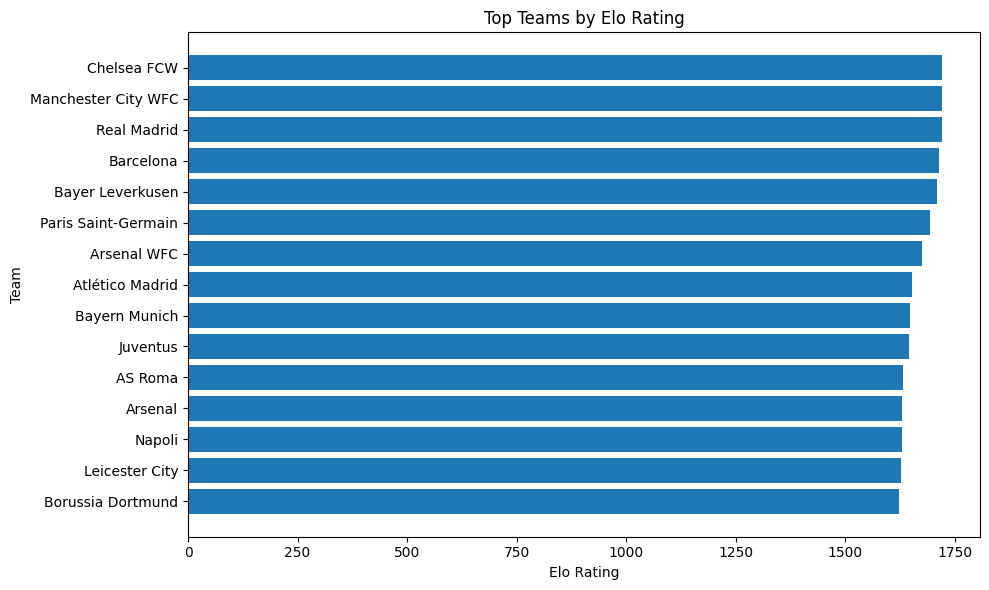

In [ ]:
# Top Elo teams
top_elo = final_elo_ratings.head(15).sort_values("elo_rating")

plt.figure(figsize=(10, 6))
plt.barh(top_elo["team"], top_elo["elo_rating"])
plt.xlabel("Elo Rating")
plt.ylabel("Team")
plt.title("Top Teams by Elo Rating")
plt.tight_layout()
plt.show()

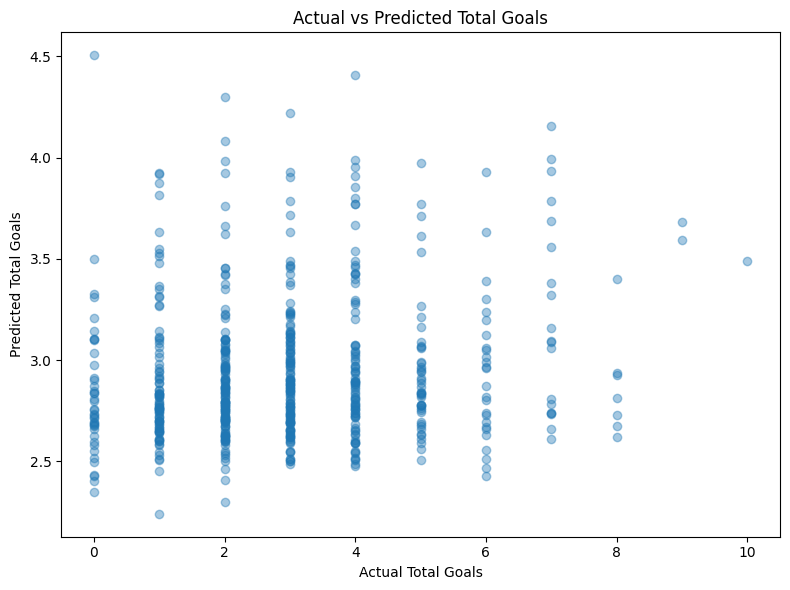

In [ ]:
# Actual vs predicted total goals
goal_eval = pd.DataFrame({
    "actual_total_goals": actual_total_goals,
    "predicted_total_goals": pred_total_goals
})

plt.figure(figsize=(8, 6))
plt.scatter(goal_eval["actual_total_goals"], goal_eval["predicted_total_goals"], alpha=0.4)
plt.xlabel("Actual Total Goals")
plt.ylabel("Predicted Total Goals")
plt.title("Actual vs Predicted Total Goals")
plt.tight_layout()
plt.show()